<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

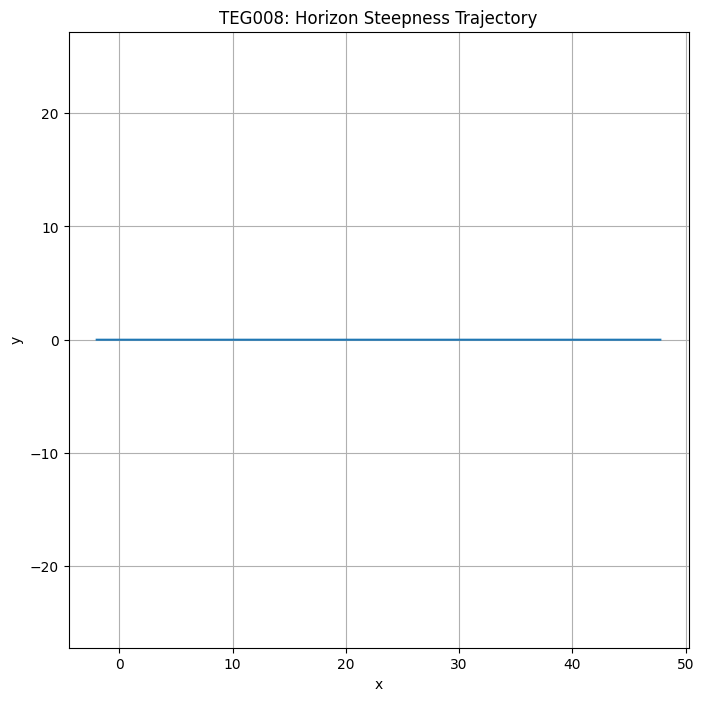

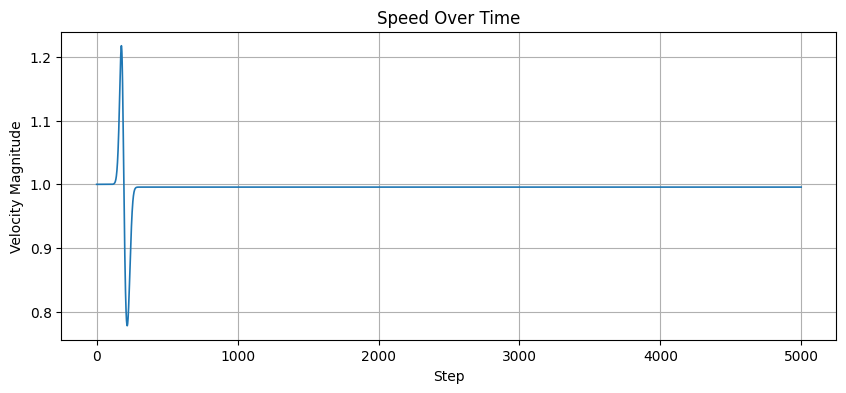

In [ ]:
# 🧬 TEG008: Horizon Steepness Scan
# Tests whether steep curvature stretches the attractor path toward effective stalling
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor (Steep Well)
def curvature_tensor(x, y, sigma=0.2, epsilon=0.8):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x**2 / sigma**2) * exp_term * (1 + epsilon)
    Cyy = (1 - y**2 / sigma**2) * exp_term * (1 - epsilon)
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma=0.2, epsilon=0.8):
    C = curvature_tensor(x, y, sigma, epsilon)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🚀 Simulation Loop with Path Stretching
def simulate_trajectory(x0, y0, vx0, vy0, steps=5000, dt=0.01, sigma=0.2, epsilon=0.8):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []
    speed_over_time = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma, epsilon)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y))
        speed_over_time.append(np.linalg.norm([vx, vy]))

    return np.array(trajectory), np.array(speed_over_time)

# 📊 Trajectory Plot
def plot_trajectory(trajectory):
    x_vals, y_vals = trajectory[:,0], trajectory[:,1]
    plt.figure(figsize=(8, 8))
    plt.plot(x_vals, y_vals, linewidth=1.5)
    plt.title("TEG008: Horizon Steepness Trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 📉 Speed Over Time Plot
def plot_speed(speed_over_time):
    plt.figure(figsize=(10, 4))
    plt.plot(speed_over_time, linewidth=1.2)
    plt.title("Speed Over Time")
    plt.xlabel("Step")
    plt.ylabel("Velocity Magnitude")
    plt.grid(True)
    plt.show()

# 🧪 Run Steepness Test
x0, y0 = -2.0, 0.0
vx0, vy0 = 1.0, 0.0  # Lightlike launch
steps = 5000
dt = 0.01
sigma = 0.2  # Steep curvature
epsilon = 0.8  # Strong asymmetry

trajectory, speed_over_time = simulate_trajectory(x0, y0, vx0, vy0, steps, dt, sigma, epsilon)
plot_trajectory(trajectory)
plot_speed(speed_over_time)
